In [1]:
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import textwrap

from data_reader import param_map
from matplotlib.patches import Patch

# Data Reading

In [2]:
eval_dir = '../../datasets/evaluations/gpt-5'
log_dir = '../../logs'

# Get models from evaluation directory (Feedback(3Iter) files)
eval_pattern = os.path.join(eval_dir, '*-Feedback(3Iter)_label.jsonl')
eval_models = set()
for eval_name in glob.glob(eval_pattern):
    model = os.path.basename(eval_name).removesuffix('-Feedback(3Iter)_label.jsonl')
    eval_models.add(model)

df = pd.DataFrame()

for model in sorted(eval_models):
    log_path = os.path.join(log_dir, f'{model}-Feedback(3Iter).jsonl')
    if not os.path.exists(log_path):
        print(f'Warning: no log file for {model}')
        continue

    log_df = pd.read_json(log_path, lines=True)
    log_df['model'] = model

    df = pd.concat([df, log_df], ignore_index=True)

df = df[df['error'].isna()].drop(columns='error')

# Data Preprocessing

In [3]:
stat_df = pd.DataFrame()
stat_df['model'] = df['model'].unique()
stat_df['__model_params'] = stat_df['model'].map(param_map)
stat_df = stat_df.sort_values('__model_params', ascending=False)

# save params for grouping (we'll use this later), then drop the column so it doesn't appear in the melt
stat_df = stat_df.set_index(['model'])
param_series = stat_df['__model_params'].copy()
stat_df = stat_df.drop(columns='__model_params')

df_copy = df.copy()

for i in range(3, 0, -1):
    col = f'it{i}_edit_answer'

    current_iteration_indicators = df_copy[col].notna()
    current_iteration_size_ser = df_copy[current_iteration_indicators].groupby(['model']).size()

    for model, cnt in current_iteration_size_ser.items():
        stat_df.at[model, f'{i} iteration{"s" if i > 1 else ""}'] = cnt

    df_copy = df_copy[~current_iteration_indicators]

no_iterations_size_ser = df_copy.groupby(['model']).size()
for model, cnt in no_iterations_size_ser.items():
        stat_df.at[model, f'Only Preproc.'] = cnt

stat_df = stat_df.fillna(0).astype(int)
# stat_df['is_model_big'] = stat_df.index.isin(big_models).astype(int)
# stat_df = stat_df.sort_values(by=['is_model_big', 'model'], ascending=[False, True]).sort_index().drop(columns='is_model_big')

# Data Visualization

C:\Users\User\AppData\Local\Temp\ipykernel_38148\2430391648.py:19: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.histplot(


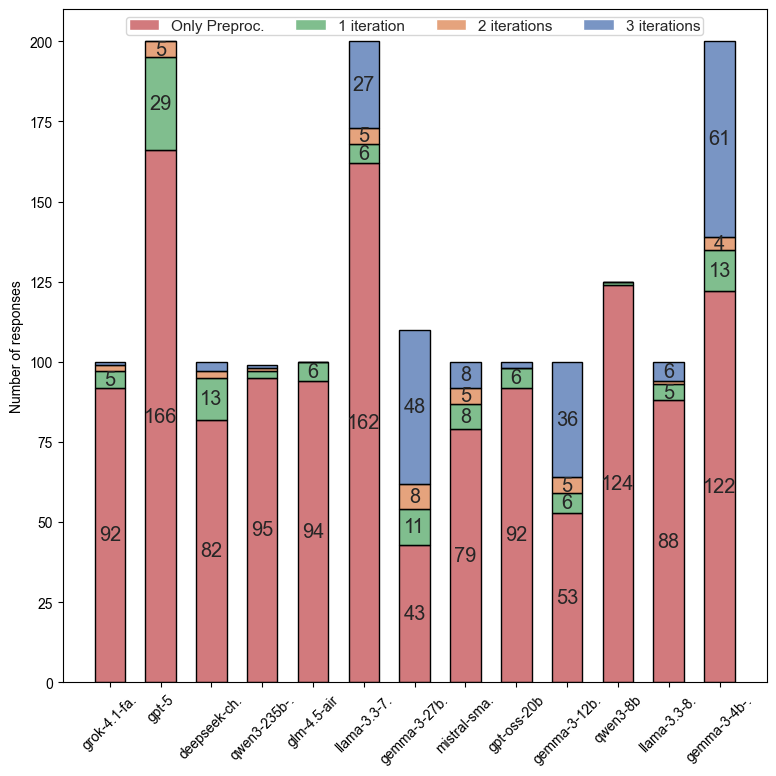

In [4]:
debug = True

df_long = stat_df.reset_index().melt(
    id_vars='model', 
    var_name='Response_Type', 
    value_name='Count',
)

fig, ax = plt.subplots(figsize=(8, 8), dpi=100 if debug else 1200)

sns.set_theme(font_scale=1.2)
sns.set_style('white')

palette = sns.color_palette()
hue_order = list(df_long['Response_Type'].unique())

x_values = df_long['model'].apply(lambda s: s[:11] + '.' if len(s) > 11 else s)

sns.histplot(
    data=df_long,
    x=x_values,
    weights='Count',
    hue='Response_Type',
    hue_order=hue_order,
    multiple='stack',
    shrink=0.6,
    palette=palette,
    edgecolor='white',
    ax=ax,
)

for i, c in enumerate(ax.containers):
    for patch in c:
        patch.set_edgecolor("black")

    labels = [str(int(v.get_height())) if v.get_height() > 3 else '' for v in c]
    
    ax.bar_label(c, labels=labels, label_type='center')

ax.set_xlabel('')
ax.set_ylabel('Number of responses')
ax.tick_params(axis='x', rotation=45, bottom=True)
ax.tick_params(axis='y', left=True)

sns.move_legend(ax, 'upper center', ncols=4, fontsize=11, title=None, reverse=True, borderpad=0.15)

plt.tight_layout()
plt.show()

if not debug:
    fig.savefig('figures/iteration_stats.pdf')

In [5]:
debug = False

df_long = stat_df.reset_index().melt(
    id_vars='model',
    var_name='Response_Type',
    value_name='Count',
)

# compute percent per model (safe against zero totals)
totals = df_long.groupby('model')['Count'].transform('sum')
df_long['Percent'] = np.where(totals == 0, 0.0, df_long['Count'] / totals * 100.0)

fig, ax = plt.subplots(figsize=(8, 8), dpi=100 if debug else 1200)

sns.set_theme(font_scale=1.2)
sns.set_style('white')

palette = sns.color_palette()
hue_order = list(df_long['Response_Type'].unique())

# --- ensure plotting order matches stat_df index order and create short labels ---
models_order = stat_df.index.tolist()                           # models sorted by params (descending)
def _short_label(s, n=11):
    return s[:n] + '.' if len(s) > n else s

short_labels = [_short_label(m) for m in models_order]

# add a short label column to df_long
df_long['model_short'] = df_long['model'].apply(_short_label)

# **CRUCIAL FIX**: make model_short a Categorical with the desired order so seaborn uses it
df_long['model_short'] = pd.Categorical(df_long['model_short'], categories=short_labels, ordered=True)

# Now call seaborn WITHOUT the 'order' kwarg (categorical dtype enforces order)
sns.histplot(
    data=df_long,
    x='model_short',
    weights='Percent',         # <-- use Percent instead of raw counts
    hue='Response_Type',
    hue_order=hue_order,
    multiple='stack',
    shrink=0.6,
    palette=palette,
    edgecolor='white',
    ax=ax,
)

# black border for each patch and percent labels in-center
for i, c in enumerate(ax.containers):
    for patch in c:
        patch.set_edgecolor("black")

    # show label only if slice > threshold (here 3%)
    labels = [f"{v.get_height():.1f}" if v.get_height() > 3 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10)

ax.set_xlabel('')
ax.set_ylabel('Percentage of responses (%)')
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.tick_params(axis='y', left=True)

# explicitly set x ticks at integer positions to match category indices
n = len(short_labels)
ax.set_xticks(range(n))
ax.set_xticklabels(short_labels, rotation=45)

sns.move_legend(ax, 'upper center', ncols=4, fontsize=11, title=None, reverse=True, borderpad=0.15)


# ---------------- draw vertical dashed lines between groups ----------------
# Determine group for each model using the saved param_series
# thresholds: big > 100B, medium 20B < params <= 100B, small <= 20B
THRESH_BIG = 100_000_000_000
THRESH_MED = 20_000_000_000

# make sure param_series is aligned to the models_order
params_aligned = param_series.reindex(models_order)

def model_group(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return 'unknown'
    # if params are strings, convert to int safe-guard
    try:
        p_val = int(p)
    except Exception:
        p_val = p
    if p_val > THRESH_BIG:
        return 'big'
    if p_val > THRESH_MED:
        return 'medium'
    return 'small'

groups = [model_group(p) for p in params_aligned]

# find indices where group changes and draw a vertical dashed line between categories
# positions are 0 .. n-1 for the categories in the order we passed to seaborn
for idx in range(1, n):
    if groups[idx] != groups[idx - 1]:
        x_pos = idx - 0.5
        ax.axvline(x=x_pos, ymin=0, ymax=1, linestyle='--', linewidth=1, color='gray')

# (optional) annotate group names above the plot (centered in each group)
from itertools import groupby
group_spans = []
for g, items in groupby(enumerate(groups), key=lambda t: t[1]):
    indices = [i for i, _ in items]
    span_start = indices[0]
    span_end = indices[-1]
    group_spans.append((g, span_start, span_end))

y_max = ax.get_ylim()[1]
for g, s, e in group_spans:
    center = (s + e) / 2.0
    if g != 'unknown':
        ax.text(center, y_max + 3, g.upper(), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

if not debug:
    fig.savefig('figures/iteration_stats.pdf')

C:\Users\User\AppData\Local\Temp\ipykernel_38148\1022277834.py:35: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.histplot(


# Inference Counts

In [7]:
# Map iteration columns to inference counts:
# Only Preproc. -> 2, 1 iteration -> 4, 2 iterations -> 6, 3 iterations -> 8
inference_map = {
    'Only Preproc.': 2,
    '1 iteration': 4,
    '2 iterations': 6,
    '3 iterations': 8,
}

# Compute inference counts per model
inference_df = stat_df.copy()
for col in inference_df.columns:
    inference_df[col] = inference_df[col] * inference_map[col]

inference_df['Total Inferences'] = inference_df.sum(axis=1)

# Total entries per model (sum of original counts)
entries_per_model = stat_df.sum(axis=1)

# Build summary table
summary = pd.DataFrame(index=stat_df.index)
summary.index.name = 'Model'
summary['Inferences per 100 Entries'] = (inference_df['Total Inferences'] / entries_per_model * 100).round().astype(int)
summary['Avg Inferences per Entry'] = (inference_df['Total Inferences'] / entries_per_model).round(2)

summary.sort_values(by='Avg Inferences per Entry')

,Inferences per 100 Entries,Avg Inferences per Entry
Model,,
qwen3-8b,202,2.02
glm-4.5-air,212,2.12
qwen3-235b-a22b,214,2.14
grok-4.1-fast,224,2.24
gpt-oss-20b,224,2.24
gpt-5,239,2.39
llama-3.3-8b-instruct,250,2.50
deepseek-chat-v3-0324,252,2.52
mistral-small-3.2-24b-instruct,284,2.84
